Setup SQLite and User Registration

In [2]:
# install libraries if not yet installed
!pip install pyotp
!pip install qrcode
!pip install bcrypt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 4.3 MB/s eta 0:00:00


**QRCode Generator**

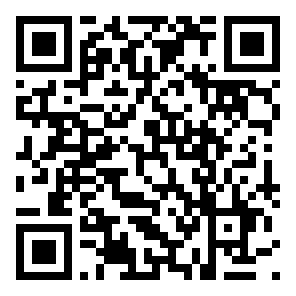

In [ ]:
import qrcode
from IPython.display import Image, display

# Function to generate and show QR code in Jupyter

def generate_qr(data: str, box_size: int = 10, border: int = 4,
                fill_color: str = "black", back_color: str = "white",
                filename: str = None):
    """
    Generate a QR code and display it in Jupyter Notebook.

    Parameters:
        data (str): Text or URL to encode.
        box_size (int): Size of each box in pixels.
        border (int): Border thickness (in boxes).
        fill_color (str): QR code color.
        back_color (str): Background color.
        filename (str, optional): If provided, saves the QR to this file.
    """
    qr = qrcode.QRCode(
        version=None,
        error_correction=qrcode.constants.ERROR_CORRECT_M,
        box_size=box_size,
        border=border,
    )
    qr.add_data(data)
    qr.make(fit=True)

    img = qr.make_image(fill_color=fill_color, back_color=back_color)

    if filename:
        img.save(filename)
        print(f"QR code saved as {filename}")

    # Show inside Jupyter
    display(img)

# Creating a QRcode for the following:
# You can try from 1 to 6 sample to generate the QR Code

# 1. URL = https://facebook.com
# 2. Telephone = tel:09214542120
# 3. SMS = smsto:09214542120:Hellooo, Musta na u?
# 4. Enail = mailto:it312@gmail.com:Testing Email
# 5. Text = Hello, I Love IT312 - Intregrative Programming
# 6. Geolocation = geo:7.3136286,125.6703633?site=DNSC



qrData = "Hello, I Love IT312 - Intregrative Programming"


# Example usage
generate_qr(qrData, box_size=8, border=2)

**SQLIte and Google Authenticator**

1. Create table using SQLite
2. Create user registration function
3. Generate QR Code for the OTP


In [ ]:
import sqlite3
import bcrypt
import pyotp
import qrcode
from IPython.display import display

# Connect to SQLite (creates file if it doesn't exist)
conn = sqlite3.connect("users.db")
cursor = conn.cursor()

# Create table for users
cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT UNIQUE NOT NULL,
    password_hash BLOB NOT NULL,
    email TEXT NOT NULL,
    secret TEXT NOT NULL
)
""")
conn.commit()

def register_user(username, password, email):
    # Check if username exists
    cursor.execute("SELECT id FROM users WHERE username = ?", (username,))
    if cursor.fetchone():
        print("⚠️ Username already exists!")
        return

    # Hash password
    hashed_pw = bcrypt.hashpw(password.encode("utf-8"), bcrypt.gensalt())

    # Generate Google Authenticator secret
    secret = pyotp.random_base32()

    # Save user into database
    cursor.execute("INSERT INTO users (username, password_hash, email, secret) VALUES (?, ?, ?, ?)",
                   (username, hashed_pw, email, secret))
    conn.commit()

    # Generate provisioning URI
    uri = pyotp.totp.TOTP(secret).provisioning_uri(
        name=email,
        issuer_name="IT312_OTP_SQLLite"
    )

    # Generate QR code for user to scan
    img = qrcode.make(uri)
    print(f"✅ User '{username}' registered successfully!")
    print("📱 Scan this QR code with Google Authenticator:")
    display(img)




**Register a new user**


**Using your Google Authenticator, scan the QRCode to create an account**

Enter your username:
user1
Enter your password:
pass123!
Enter your email:
user1@gmail.com
✅ User 'user1' registered successfully!
📱 Scan this QR code with Google Authenticator:


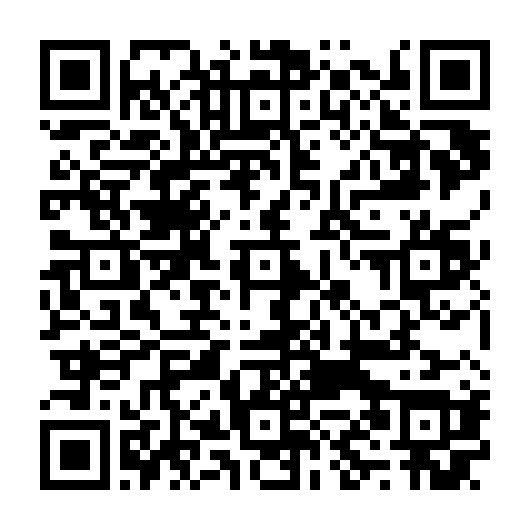

In [ ]:

print("Enter your username:")
username = input()

print("Enter your password:")
password = input()

print("Enter your email:")
email = input()

register_user(username, password, email)

**Function for Login with Username + Password + OTP**

In [ ]:
def login(username, password):
    # Fetch user record
    cursor.execute("SELECT password_hash, secret FROM users WHERE username = ?", (username,))
    row = cursor.fetchone()

    if not row:
        print("❌ Invalid username")
        return False

    stored_pw, secret = row

    # Verify password
    if not bcrypt.checkpw(password.encode("utf-8"), stored_pw):
        print("❌ Invalid password")
        return False

    # Prompt for OTP
    totp = pyotp.TOTP(secret)
    otp = input("Enter the 6-digit code from Google Authenticator: ")

    if totp.verify(otp):
        print(f"✅ Login successful! Welcome, {username}")
        return True
    else:
        print("❌ Invalid OTP")
        return False


**Login user**

In [ ]:

print("Enter your username:")
username = input()

print("Enter your password:")
password = input()

login(username,password)

Enter your username:
user1
Enter your password:
pass123!
Enter the 6-digit code from Google Authenticator: 702226
✅ Login successful! Welcome, user1


True

**JOKE API's**

In [12]:
import requests

response = requests.get("https://v2.jokeapi.dev/joke/Programming?type=single")
joke = response.json()["joke"]

print(joke)

Saying that Java is nice because it works on every OS is like saying that anal sex is nice because it works on every gender.


In [14]:
import requests

# Fetch a joke
joke = requests.get("https://v2.jokeapi.dev/joke/Any?safe-mode").json()

# Display the joke nicely
if joke["type"] == "single":
    display_text = joke["joke"]
else:
    display_text = f"{joke['setup']}\n{joke['delivery']}"

print(display_text)

What's the best thing about Switzerland?
I don't know, but the flag is a big plus.


**Acitivity: Modify the login with sql, and after successfull login, call any of the joke API's and generate the QR code for the text (joke message/text).**

1 Login 
2 Register
Enter a choice: 1
 
Enter your username: Kobe
Enter your password: kobedu123
Enter the 6-digit code from Google Authenticator: 381859
✅ Login successful! Welcome, Kobe!

Here's the joke: 
Why was the JavaScript developer sad?
Because they didn't Node how to Express themself!
 


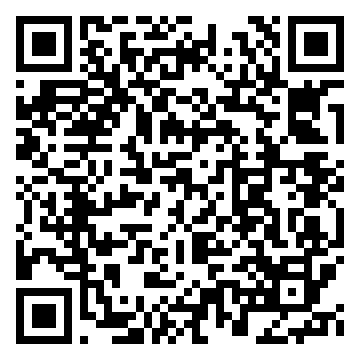

In [21]:
import sqlite3
import bcrypt
import pyotp
import qrcode
import requests
from IPython.display import display

# Connect to SQLite (creates file if it doesn't exist)
conn = sqlite3.connect("users.db")
cursor = conn.cursor()

# Create table for users
cursor.execute("""
CREATE TABLE IF NOT EXISTS users (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    username TEXT UNIQUE NOT NULL,
    password_hash BLOB NOT NULL,
    email TEXT NOT NULL,
    secret TEXT NOT NULL
)
""")
conn.commit()

def register_user(username, password, email):
    # Check if username exists
    cursor.execute("SELECT id FROM users WHERE username = ?", (username,))
    if cursor.fetchone():
        print("⚠️ Username already exists!")
        return

    # Hash password
    hashed_pw = bcrypt.hashpw(password.encode("utf-8"), bcrypt.gensalt())

    # Generate Google Authenticator secret
    secret = pyotp.random_base32()

    # Save user into database
    cursor.execute("INSERT INTO users (username, password_hash, email, secret) VALUES (?, ?, ?, ?)",
                   (username, hashed_pw, email, secret))
    conn.commit()

    # Generate provisioning URI
    uri = pyotp.totp.TOTP(secret).provisioning_uri(
        name=email,
        issuer_name="IT312_OTP_SQLLite"
    )

    # Generate QR code for user to scan
    img = qrcode.make(uri)
    print(f"✅ User '{username}' registered successfully!")
    print("📱 Scan this QR code with Google Authenticator:")
    display(img)

def login(username, password):
    # Fetch user record
    cursor.execute("SELECT password_hash, secret FROM users WHERE username = ?", (username,))
    row = cursor.fetchone()

    if not row:
        print("❌ Invalid username")
        return False

    stored_pw, secret = row

    # Verify password
    if not bcrypt.checkpw(password.encode("utf-8"), stored_pw):
        print("❌ Invalid password")
        return False

    # Prompt for OTP
    totp = pyotp.TOTP(secret)
    otp = input("Enter the 6-digit code from Google Authenticator: ")

    if totp.verify(otp):
        print(f"✅ Login successful! Welcome, {username}!")
        fetchJoke()
        return True
    else:
        print("❌ Invalid OTP")
        return False

def generate_qr(data: str, box_size: int = 10, border: int = 4,
                fill_color: str = "black", back_color: str = "white",
                filename: str = None):

    qr = qrcode.QRCode(
        version=None,
        error_correction=qrcode.constants.ERROR_CORRECT_M,
        box_size=box_size,
        border=border,
    )
    qr.add_data(data)
    qr.make(fit=True)

    img = qr.make_image(fill_color=fill_color, back_color=back_color)

    if filename:
        img.save(filename)
        print(f"QR code saved as {filename}")

    # Show inside Jupyter
    display(img)


def fetchJoke():
  # Fetch a joke
  joke = requests.get("https://v2.jokeapi.dev/joke/Any?safe-mode").json()

  # Display the joke nicely
  if joke["type"] == "single":
    display_text = joke["joke"]
  else:
    display_text = f"{joke['setup']}\n{joke['delivery']}"

  print("\nHere's the joke: ")
  print(display_text)

  print(" ")
  qrData = display_text
  generate_qr(qrData, box_size=8, border=2)


print("1 Login \n2 Register")
choice1 = int(input("Enter a choice: "))

if choice1 == 2:
  print(" ")
  username = input("Enter your username: ")

  password = input("Enter your password: ")

  email = input("Enter your email: ")

  register_user(username, password, email)
elif choice1 == 1:
  print(" ")
  username = input("Enter your username: ")

  password = input("Enter your password: ")

  login(username,password)




